# Lectura y exploración de datos

En este tutorial aprenderemos a cargar un dataset y a obtener una primera descripción de su contenido. Usaremos una base sencilla de ventas para practicar inspección inicial, estadísticas descriptivas y comparaciones por grupos.

## Requisitos

Para desarrollar este tutorial necesitarás:

* Importar librerías en Python.
* Leer archivos `.csv` con `pandas`.
* Consultar columnas y filas de un `DataFrame`.

## Objetivos

Al final de este tutorial podrás:

**1.** Leer un dataset y reconocer su estructura básica. <br>
**2.** Usar métodos de exploración inicial como `head`, `info` y `describe`. <br>
**3.** Resumir variables categóricas y numéricas. <br>
**4.** Responder preguntas sencillas a partir del dataset.

## 1. Importar librerías y leer el archivo

In [1]:
from pathlib import Path
import pandas as pd

ruta = Path("Archivos") / "ventas_tienda.csv"
ventas = pd.read_csv(ruta, parse_dates=["fecha"])
ventas.head()

,pedido_id,fecha,ciudad,categoria,canal,unidades,precio_unitario,descuento_pct,calificacion_cliente
0,1001,2025-01-05,Bogota,Tecnologia,Web,3,180000,0.10,4.8
1,1002,2025-01-08,Medellin,Hogar,Tienda,5,95000,0.05,4.4
2,1003,2025-01-15,Cali,Tecnologia,App,2,320000,0.15,4.9
3,1004,2025-01-22,Barranquilla,Deportes,Web,4,120000,0.00,4.3
4,1005,2025-02-02,Bogota,Hogar,Tienda,6,85000,0.08,4.2


`parse_dates=["fecha"]` le indica a `pandas` que esa columna debe interpretarse como fecha. Esto facilita análisis por mes o por periodo.

## 2. Explorar la estructura general

In [2]:
print("Dimensiones:", ventas.shape)
print("\nColumnas:")
print(list(ventas.columns))

Dimensiones: (16, 9)

Columnas:
['pedido_id', 'fecha', 'ciudad', 'categoria', 'canal', 'unidades', 'precio_unitario', 'descuento_pct', 'calificacion_cliente']


In [3]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   pedido_id             16 non-null     int64         
 1   fecha                 16 non-null     datetime64[ns]
 2   ciudad                16 non-null     object        
 3   categoria             16 non-null     object        
 4   canal                 16 non-null     object        
 5   unidades              16 non-null     int64         
 6   precio_unitario       16 non-null     int64         
 7   descuento_pct         16 non-null     float64       
 8   calificacion_cliente  16 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 1.2+ KB


Observa cuántas filas hay, qué tipo de dato tiene cada columna y si parece haber variables categóricas, numéricas y temporales.

## 3. Crear una variable de ingreso

Nuestro archivo contiene unidades, precio y descuento. Con esa información podemos calcular el ingreso neto por pedido.

In [4]:
ventas["ingreso"] = ventas["unidades"] * ventas["precio_unitario"] * (1 - ventas["descuento_pct"])
ventas.head()

,pedido_id,fecha,ciudad,categoria,canal,unidades,precio_unitario,descuento_pct,calificacion_cliente,ingreso
0,1001,2025-01-05,Bogota,Tecnologia,Web,3,180000,0.10,4.8,486000.0
1,1002,2025-01-08,Medellin,Hogar,Tienda,5,95000,0.05,4.4,451250.0
2,1003,2025-01-15,Cali,Tecnologia,App,2,320000,0.15,4.9,544000.0
3,1004,2025-01-22,Barranquilla,Deportes,Web,4,120000,0.00,4.3,480000.0
4,1005,2025-02-02,Bogota,Hogar,Tienda,6,85000,0.08,4.2,469200.0


## 4. Estadísticas descriptivas para variables numéricas

`describe()` resume conteo, media, dispersión y percentiles.

In [5]:
ventas[["unidades", "precio_unitario", "descuento_pct", "calificacion_cliente", "ingreso"]].describe()

,unidades,precio_unitario,descuento_pct,calificacion_cliente,ingreso
count,16.000000,16.000000,16.000000,16.000000,16.000000
mean,4.437500,164562.500000,0.091250,4.481250,487151.875000
std,2.308499,117783.399368,0.056199,0.288025,128855.767907
min,1.000000,65000.000000,0.000000,4.000000,297000.000000
25%,2.750000,88750.000000,0.050000,4.275000,418625.000000
50%,4.000000,115000.000000,0.095000,4.450000,474600.000000
75%,6.000000,187500.000000,0.120000,4.725000,547650.000000
max,9.000000,450000.000000,0.200000,4.900000,781200.000000


Algunas preguntas que podemos responder aquí son:

* ¿Cuántas unidades se venden normalmente por pedido?
* ¿Cuál es el rango de precios?
* ¿Los descuentos suelen ser bajos o altos?

## 5. Explorar variables categóricas

En variables de texto, una revisión útil es contar cuántas veces aparece cada categoría.

In [6]:
ventas["ciudad"].value_counts()

ciudad
Bogota          4
Medellin        4
Cali            3
Barranquilla    2
Cartagena       2
Bucaramanga     1
Name: count, dtype: int64

In [7]:
ventas["categoria"].value_counts(normalize=True).round(2)

categoria
Tecnologia    0.31
Hogar         0.31
Deportes      0.19
Moda          0.19
Name: proportion, dtype: float64

El argumento `normalize=True` devuelve proporciones en lugar de frecuencias absolutas.

## 6. Resúmenes por grupo

Una vez entendemos las variables, podemos compararlas entre grupos. Por ejemplo, podemos resumir el ingreso por ciudad o por categoría.

In [8]:
ventas.groupby("ciudad")["ingreso"].agg(["count", "mean", "sum"]).round(2).sort_values("sum", ascending=False)

,count,mean,sum
ciudad,,,
Medellin,4,545762.50,2183050.0
Bogota,4,511150.00,2044600.0
Cali,3,446833.33,1340500.0
Barranquilla,2,574400.00,1148800.0
Cartagena,2,388740.00,777480.0
Bucaramanga,1,300000.00,300000.0


In [9]:
ventas.groupby("categoria")[["unidades", "ingreso", "calificacion_cliente"]].mean().round(2)

,unidades,ingreso,calificacion_cliente
categoria,,,
Deportes,6.0,498733.33,4.40
Hogar,5.2,466546.00,4.28
Moda,5.0,352666.67,4.33
Tecnologia,2.4,581500.00,4.82


## 7. Explorar el tiempo

Como la columna `fecha` ya es de tipo fecha, podemos resumir ventas por mes.

In [10]:
ventas["mes"] = ventas["fecha"].dt.to_period("M")
ventas.groupby("mes")["ingreso"].sum().round(2)

mes
2025-01    1961250.0
2025-02    1585700.0
2025-03    1907800.0
2025-04    2339680.0
Freq: M, Name: ingreso, dtype: float64

## 8. Responder preguntas simples

La exploración tiene más sentido cuando se conecta con preguntas concretas.

In [11]:
ciudad_top = ventas.groupby("ciudad")["ingreso"].sum().idxmax()
categoria_top = ventas.groupby("categoria")["ingreso"].sum().idxmax()
promedio_calificacion = ventas["calificacion_cliente"].mean()

print("Ciudad con mayor ingreso total:", ciudad_top)
print("Categoria con mayor ingreso total:", categoria_top)
print("Calificacion promedio de clientes:", round(promedio_calificacion, 2))

Ciudad con mayor ingreso total: Medellin
Categoria con mayor ingreso total: Tecnologia
Calificacion promedio de clientes: 4.48


## 9. Visualización rápida

Una figura sencilla puede complementar la exploración descriptiva.

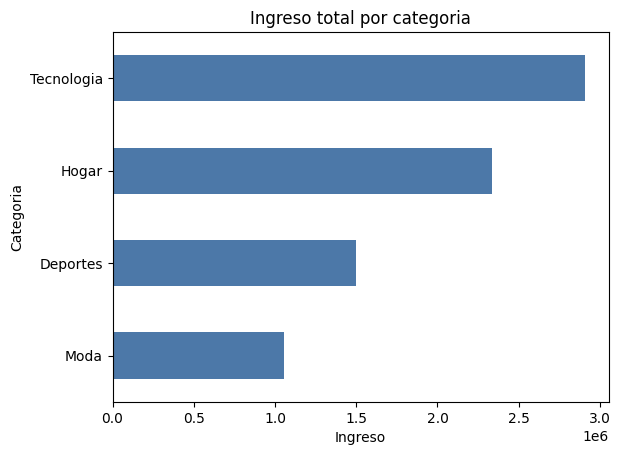

In [12]:
import matplotlib.pyplot as plt

ventas.groupby("categoria")["ingreso"].sum().sort_values().plot(kind="barh", color="#4C78A8")
plt.title("Ingreso total por categoria")
plt.xlabel("Ingreso")
plt.ylabel("Categoria")
plt.show()

## Idea final

Explorar datos es aprender a formular preguntas iniciales sobre un dataset. Si conocemos su estructura y resumimos bien su contenido, tomaremos mejores decisiones en las siguientes etapas del análisis.